# 03 · What does a 360 snapshot miss? A velocity and visibility study

StatsBomb 360 frames (which M1 and M2 are built on) have **no velocities** and show only **players on the
broadcast camera**. Using SkillCorner's open broadcast tracking (20 A-League 2024/25 matches, MIT licence),
we predict pass completion under four information conditions, evaluated on the same passes:

| condition | players | velocities | mimics |
|---|---|---|---|
| full_vel | all (detected + extrapolated) | ✓ | full tracking |
| full_pos | all | – | a perfect snapshot |
| vis_vel | on screen only | ✓ | broadcast tracking, visible players |
| vis_pos | on screen only | – | **StatsBomb 360** |

Leave-one-match-out predictions; bootstrap CIs over 10-minute match blocks. Data: SkillCorner.

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from phds.data.freeze_frames import PROCESSED_DIR, load_table
from phds.eval.metrics import fmt_ci, cluster_bootstrap, auc

OUT = Path("../reports/m3"); OUT.mkdir(parents=True, exist_ok=True)
res = json.loads((OUT / "velocity_study.json").read_text())
pred = np.load(OUT / "velocity_study_predictions.npz", allow_pickle=True)
tp = pd.read_parquet(PROCESSED_DIR / "tracking_passes.parquet")
s = tp[tp["passer_detected"] & tp["target_detected"]].reset_index(drop=True)
assert len(s) == len(pred["y"])
print(f"{res['n_passes']:,} passes; analysis sample {res['n_sample']:,} (completion {res['completion']:.3f}); "
      f"target on screen {res['target_on_screen']:.1%}; median players on screen {res['median_on_screen']:.0f}")

15,937 passes; analysis sample 12,867 (completion 0.858); target on screen 81.7%; median players on screen 15


## 1. Is "on screen" really 360-like?

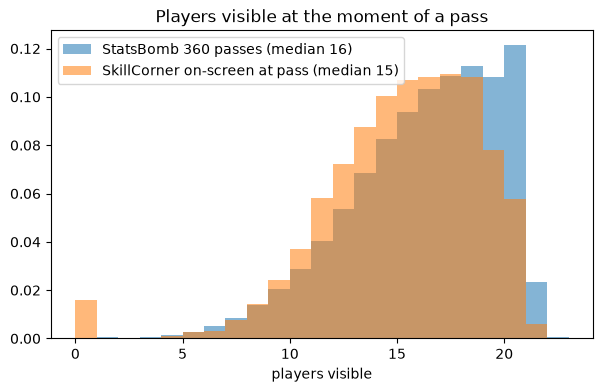

In [2]:
frames = load_table("frames", columns=["event_id", "n_players"])
ev = load_table("events", columns=["event_id", "type"])
sb = frames.merge(ev[ev["type"] == "Pass"], on="event_id")["n_players"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sb, bins=np.arange(0, 24), density=True, alpha=.55, label=f"StatsBomb 360 passes (median {sb.median():.0f})")
ax.hist(tp["n_detected"], bins=np.arange(0, 24), density=True, alpha=.55, label=f"SkillCorner on-screen at pass (median {tp['n_detected'].median():.0f})")
ax.set(xlabel="players visible", title="Players visible at the moment of a pass"); ax.legend()
fig.savefig(OUT / "visibility_comparison.png", dpi=140, bbox_inches="tight")

## 2. Results by model and condition

In [3]:
tab = pd.DataFrame([{"model": r["model"], "condition": r["condition"], "log loss": fmt_ci(r["log_loss"]),
                     "AUC": fmt_ci(r["auc"]), "ECE": round(r["ece"], 3), "mean pred": round(r["mean_pred"], 3)}
                    for r in res["rows"]]).set_index(["model", "condition"])
display(tab)
print("SkillCorner's own xpass_completion (reference):", fmt_ci(res["skillcorner_xpass_auc"]))

,,log loss,AUC,ECE,mean pred
model,condition,,,,
physics,full_vel,"0.314 [0.301, 0.328]","0.832 [0.822, 0.843]",0.006,0.858
lgbm,full_vel,"0.292 [0.278, 0.306]","0.864 [0.854, 0.872]",0.008,0.860
physics_nested,full_vel,"0.299 [0.286, 0.313]","0.854 [0.844, 0.863]",0.007,0.858
physics,full_pos,"0.300 [0.287, 0.313]","0.853 [0.843, 0.862]",0.005,0.858
lgbm,full_pos,"0.295 [0.282, 0.309]","0.859 [0.850, 0.868]",0.008,0.859
physics,vis_vel,"0.319 [0.306, 0.332]","0.826 [0.815, 0.835]",0.003,0.858
lgbm,vis_vel,"0.293 [0.279, 0.307]","0.863 [0.853, 0.871]",0.007,0.860
physics_nested,vis_vel,"0.304 [0.291, 0.319]","0.847 [0.837, 0.856]",0.005,0.858
physics,vis_pos,"0.304 [0.291, 0.318]","0.847 [0.837, 0.855]",0.005,0.858


SkillCorner's own xpass_completion (reference): 0.900 [0.891, 0.908]


Δ log loss (a − b)  \
model          contrast                                                                     
physics        velocity (all players)                             0.0140 [0.0115, 0.0169]   
               velocity (on-screen players)                       0.0145 [0.0117, 0.0175]   
               visibility (no velocity)                        -0.0047 [-0.0072, -0.0025]   
               visibility (with velocity)                      -0.0051 [-0.0081, -0.0027]   
               total: full tracking vs 360-like                   0.0093 [0.0059, 0.0127]   
lgbm           velocity (all players)                          -0.0036 [-0.0055, -0.0016]   
               velocity (on-screen players)                    -0.0033 [-0.0050, -0.0014]   
               visibility (no velocity)                         -0.0006 [-0.0025, 0.0011]   
               visibility (with velocity)                       -0.0009 [-0.0031, 0.0012]   
               total: full tracking vs 360-like                -0.0041 [-0.0069, -0.0016]   
physics_nested velocity added to static margins (all players)   -0.0005 [-0.0015, 0.0004]   
               velocity added to static margins (on-screen)      0.0001 [-0.0008, 0.0013]   

                                                                         Δ AUC (a − b)  
model          contrast                                                                 
physics        velocity (all players)                          -0.021 [-0.025, -0.017]  
               velocity (on-screen players)                    -0.021 [-0.026, -0.017]  
               visibility (no velocity)                           0.006 [0.003, 0.009]  
               visibility (with velocity)                         0.007 [0.004, 0.010]  
               total: full tracking vs 360-like                -0.015 [-0.020, -0.010]  
lgbm           velocity (all players)                             0.004 [0.002, 0.007]  
               velocity (on-screen players)                       0.005 [0.002, 0.007]  
               visibility (no velocity)                          0.001 [-0.001, 0.004]  
               visibility (with velocity)                        0.001 [-0.001, 0.004]  
               total: full tracking vs 360-like                   0.006 [0.003, 0.009]  
physics_nested velocity added to static margins (all players)    0.001 [-0.000, 0.002]  
               velocity added to static margins (on-screen)      0.000 [-0.001, 0.001]

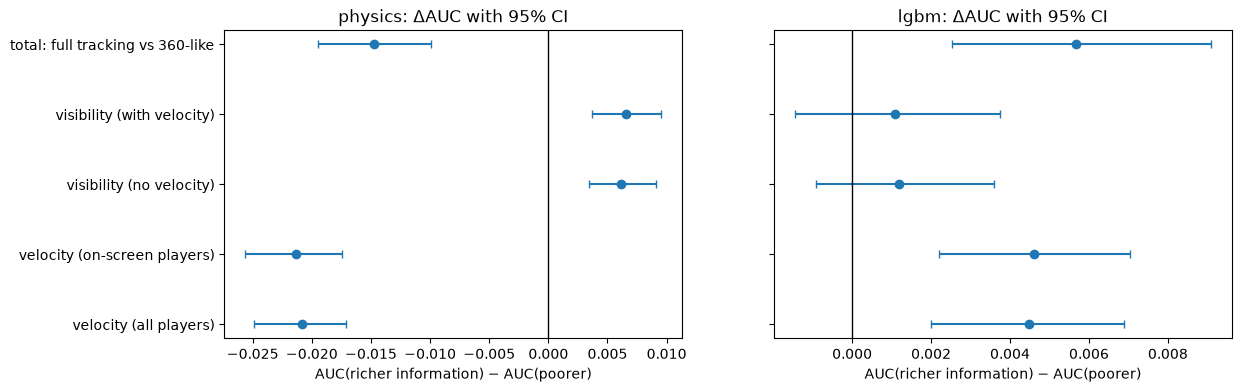

In [4]:
con = pd.DataFrame([{"model": k.split(": ")[0], "contrast": k.split(": ", 1)[1], "Δ log loss (a − b)": fmt_ci(v["log_loss_diff"], digits=4),
                     "Δ AUC (a − b)": fmt_ci(v["auc_diff"])} for k, v in res["contrasts"].items()]).set_index(["model", "contrast"])
display(con)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, model in zip(axes, ["physics", "lgbm"]):
    items = [(k.split(": ", 1)[1], v["auc_diff"]) for k, v in res["contrasts"].items() if k.split(": ", 1)[0] == model]
    labels = [i[0] for i in items]; pts = np.array([i[1] for i in items])
    ax.errorbar(pts[:, 0], range(len(items)), xerr=[pts[:, 0] - pts[:, 1], pts[:, 2] - pts[:, 0]], fmt="o", capsize=3)
    ax.axvline(0, c="k", lw=1); ax.set_yticks(range(len(items))); ax.set_yticklabels(labels)
    ax.set(title=f"{model}: ΔAUC with 95% CI", xlabel="AUC(richer information) − AUC(poorer)")
fig.savefig(OUT / "contrasts.png", dpi=140, bbox_inches="tight")

## 3. Where do velocities matter?
Velocity-driven gains should concentrate where movement changes the outcome: longer passes (more time for
defenders to close) and fast-moving receivers or defenders.

In [5]:
y, blocks = pred["y"], pred["block"]
s["length_bin"] = pd.cut(s["full_vel__length"], [0, 15, 30, 200], labels=["short <15yd", "medium 15-30", "long >30"])
s["recv_speed_bin"] = pd.qcut(s["full_vel__receiver_speed"], 3, labels=["slow receiver", "mid", "fast receiver"])
rows = []
for col in ["length_bin", "recv_speed_bin"]:
    for level, idx in s.groupby(col, observed=True).groups.items():
        i = np.asarray(idx)
        for model in ["physics", "lgbm"]:
            a, b = pred[f"{model}__full_vel"][i], pred[f"{model}__full_pos"][i]
            ci = cluster_bootstrap(lambda j, a=a, b=b, yy=y[i]: auc(a[j], yy[j]) - auc(b[j], yy[j]), blocks[i], n_boot=300)
            rows.append({"split": col, "group": level, "passes": len(i), "failures": int((1 - y[i]).sum()), "model": model,
                         "ΔAUC velocity (all players)": fmt_ci(ci)})
display(pd.DataFrame(rows).set_index(["split", "group", "model"]))

passes  failures  \
split          group         model                       
length_bin     short <15yd   physics    6057       761   
                             lgbm       6057       761   
               medium 15-30  physics    5946       775   
                             lgbm       5946       775   
               long >30      physics     864       289   
                             lgbm        864       289   
recv_speed_bin slow receiver physics    4289       478   
                             lgbm       4289       478   
               mid           physics    4289       506   
                             lgbm       4289       506   
               fast receiver physics    4289       841   
                             lgbm       4289       841   

                                     ΔAUC velocity (all players)  
split          group         model                                
length_bin     short <15yd   physics     -0.039 [-0.049, -0.031]  
                             lgbm           0.007 [0.002, 0.013]  
               medium 15-30  physics     -0.017 [-0.021, -0.013]  
                             lgbm           0.004 [0.002, 0.007]  
               long >30      physics       0.002 [-0.006, 0.012]  
                             lgbm         -0.001 [-0.009, 0.006]  
recv_speed_bin slow receiver physics     -0.007 [-0.011, -0.002]  
                             lgbm          0.003 [-0.000, 0.005]  
               mid           physics     -0.016 [-0.024, -0.010]  
                             lgbm          0.001 [-0.002, 0.005]  
               fast receiver physics     -0.039 [-0.048, -0.030]  
                             lgbm           0.009 [0.004, 0.013]

### Which velocity information does the learned model use?
Gain importance of a LightGBM fit on all analysis passes (full_vel features), plus a targeted ablation:
static features + receiver movement only vs static features + defender velocity margins only.

In [6]:
import lightgbm as lgb
from phds.features.pass_features import PASS_FEATURES
from phds.features.tracking_passes import VELOCITY_FEATURES
cols = [f"full_vel__{c}" for c in PASS_FEATURES + VELOCITY_FEATURES if s[f"full_vel__{c}"].notna().any()]
m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=40, subsample=0.8,
                       subsample_freq=1, colsample_bytree=0.8, reg_lambda=2.0, verbose=-1).fit(s[cols], y)
gain = pd.Series(m.booster_.feature_importance("gain"), index=[c.split("__")[1] for c in cols])
gain = (gain / gain.sum()).sort_values(ascending=False)
display(gain.head(12).round(3).to_frame("gain share"))
print("velocity features' total gain share:", round(gain[[c for c in VELOCITY_FEATURES if c in gain]].sum(), 3))

def lomo(feature_cols):
    pred = np.zeros(len(s))
    for mid in s["match_id"].unique():
        te = (s["match_id"] == mid).to_numpy()
        mm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=40, subsample=0.8,
                                subsample_freq=1, colsample_bytree=0.8, reg_lambda=2.0, verbose=-1)
        pred[te] = mm.fit(s.loc[~te, feature_cols], y[~te]).predict_proba(s.loc[te, feature_cols])[:, 1]
    return pred
static = [f"full_pos__{c}" for c in PASS_FEATURES if s[f"full_pos__{c}"].notna().any()]
receiver = [f"full_vel__{c}" for c in ["receiver_speed", "receiver_v_along", "receiver_v_across", "passer_speed"]]
defender = [f"full_vel__{c}" for c in ["dyn_lane_margin", "dyn_target_margin", "dyn_physics_margin", "max_defender_closing_speed"]]
base = pred["lgbm__full_pos"]
for label, extra in [("+ receiver/passer movement", receiver), ("+ defender velocity margins", defender)]:
    pa = lomo(static + extra)
    ci = cluster_bootstrap(lambda j, pa=pa: auc(pa[j], y[j]) - auc(base[j], y[j]), blocks, n_boot=300)
    print(f"static {label}: ΔAUC vs static only {fmt_ci(ci)}")

,gain share
physics_margin,0.235
target_margin,0.185
lane_margin,0.081
target_opp_nearest,0.075
passer_opp_nearest,0.040
lane_min_perp,0.036
receiver_v_along,0.035
passer_speed,0.030
receiver_speed,0.026
passer_x,0.023


velocity features' total gain share: 0.168


static + receiver/passer movement: ΔAUC vs static only 0.006 [0.003, 0.008]


static + defender velocity margins: ΔAUC vs static only 0.000 [-0.001, 0.002]


## 4. Does the StatsBomb-trained M2 model transfer?
The M2 completion model was trained only on StatsBomb 360 frames from other competitions. Here it's applied,
unchanged, to A-League broadcast tracking converted to the same features: a different league, data provider
and tracking technology.

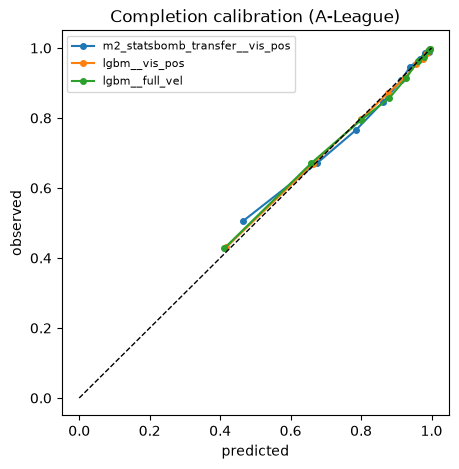

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
from phds.eval.metrics import reliability_bins
for name in ["m2_statsbomb_transfer__vis_pos", "lgbm__vis_pos", "lgbm__full_vel"]:
    rb = np.array(reliability_bins(pred[name], y, n_bins=10)); ax.plot(rb[:, 0], rb[:, 1], "o-", ms=4, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1); ax.set(xlabel="predicted", ylabel="observed", title="Completion calibration (A-League)"); ax.legend(fontsize=8)
fig.savefig(OUT / "transfer_calibration.png", dpi=140, bbox_inches="tight")